In [ ]:
import pandas as pd
df = pd.read_csv(r"/content/job_descriptions.csv", engine='python', on_bad_lines='skip')

In [ ]:
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
pip install pandas openpyxl nltk

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


Shape: (109794, 23)

Columns:
['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']


In [ ]:
possible_columns = [
    "Job Description",
    "job_description",
    "JobDescription",
    "description",
    "Description"
]

jd_column = None

for column in possible_columns:
    if column in df.columns:
        jd_column = column
        break

if jd_column is None:
    print("\nJob Description column not found.")
    print("Available columns:")
    print(df.columns.tolist())
    raise ValueError(
        "Please change 'jd_column' to your actual Job Description column name."
    )

print("\nUsing column:", jd_column)



Using column: Job Description


In [ ]:
df[jd_column] = df[jd_column].fillna("").astype(str)


In [ ]:
import pandas as pd
import nltk
import re

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer


In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

In [ ]:
def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens
df["Tokens"] = df[jd_column].apply(tokenize_text)


In [ ]:
def lowercase_tokens(tokens):
    return [token.lower() for token in tokens]
df["Lowercase Tokens"] = df["Tokens"].apply(lowercase_tokens)


In [ ]:
def remove_stopwords(tokens):
    cleaned_tokens = []
    for token in tokens:
        # Keep only alphabetic words
        if token.isalpha():
            if token not in stop_words:
                cleaned_tokens.append(token)
    return cleaned_tokens
df["After Stopword Removal"] = (
    df["Lowercase Tokens"].apply(remove_stopwords)
)


In [ ]:
def lemmatize_tokens(tokens):
    return [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]
df["Lemmatized Tokens"] = (
    df["After Stopword Removal"].apply(lemmatize_tokens)
)


In [ ]:
def stem_tokens(tokens):
    return [
        stemmer.stem(token)
        for token in tokens
    ]
df["Stemmed Tokens"] = (
    df["After Stopword Removal"].apply(stem_tokens)
)

In [ ]:
def sentence_segmentation(text):
    sentences = sent_tokenize(text)
    return sentences
df["Sentence Segmentation"] = (
    df[jd_column].apply(sentence_segmentation)
)


In [ ]:

df["Token Count"] = df["Tokens"].apply(len)
df["Clean Token Count"] = (
    df["After Stopword Removal"].apply(len)
)
df["Sentence Count"] = (
    df["Sentence Segmentation"].apply(len)
)



In [ ]:
df["Tokens"] = df["Tokens"].apply(
    lambda x: ", ".join(x)
)

df["Lowercase Tokens"] = df["Lowercase Tokens"].apply(
    lambda x: ", ".join(x)
)

df["After Stopword Removal"] = df[
    "After Stopword Removal"
].apply(
    lambda x: ", ".join(x)
)

df["Lemmatized Tokens"] = df[
    "Lemmatized Tokens"
].apply(
    lambda x: ", ".join(x)
)

df["Stemmed Tokens"] = df[
    "Stemmed Tokens"
].apply(
    lambda x: ", ".join(x)
)

df["Sentence Segmentation"] = df[
    "Sentence Segmentation"
].apply(
    lambda x: " | ".join(x)
)


In [ ]:
print("\n==========================================")
print("NLP PREPROCESSING EXAMPLE")
print("==========================================")

print("\nOriginal:")
print(df[jd_column].iloc[0])

print("\nTokens:")
print(df["Tokens"].iloc[0])

print("\nLowercase:")
print(df["Lowercase Tokens"].iloc[0])

print("\nAfter Stopword Removal:")
print(df["After Stopword Removal"].iloc[0])

print("\nLemmatization:")
print(df["Lemmatized Tokens"].iloc[0])

print("\nStemming:")
print(df["Stemmed Tokens"].iloc[0])

print("\nSentence Segmentation:")
print(df["Sentence Segmentation"].iloc[0])



NLP PREPROCESSING EXAMPLE

Original:
Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.

Tokens:
Social, Media, Managers, oversee, an, organizations, social, media, presence, ., They, create, and, schedule, content, ,, engage, with, followers, ,, and, analyze, social, media, metrics, to, drive, brand, awareness, and, engagement, .

Lowercase:
social, media, managers, oversee, an, organizations, social, media, presence, ., they, create, and, schedule, content, ,, engage, with, followers, ,, and, analyze, social, media, metrics, to, drive, brand, awareness, and, engagement, .

After Stopword Removal:
social, media, managers, oversee, organizations, social, media, presence, create, schedule, content, engage, followers, analyze, social, media, metrics, drive, brand, awareness, engagement

Lemmatization:
social, medium, manager, oversee, orga

In [ ]:
skills = [
    "python",
    "sql",
    "power bi",
    "tableau",
    "excel",
    "aws",
    "azure",
    "java",
    "javascript",
    "r",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "spark",
    "docker",
    "mysql",
    "postgresql",
    "mongodb",
    "git",
    "github"
]


In [ ]:
def extract_skills(text):

    found = []

    # Convert text to lowercase
    text = str(text).lower()

    for skill in skills:

        # Escape special characters
        pattern = r"\b" + re.escape(skill.lower()) + r"\b"

        # Search skill in job description
        if re.search(pattern, text):

            found.append(skill)

    return found


In [ ]:
for index, row in df.head(10).iterrows():
    print("\nJob Description:")
    print(row["Job Description"])
    print("\nExtracted Skills:")
    print(row["Extracted Skills"])
    print("------------------------------------------")


Job Description:
Social Media Managers oversee an organizations social media presence. They create and schedule content, engage with followers, and analyze social media metrics to drive brand awareness and engagement.

Extracted Skills:
[]
------------------------------------------

Job Description:
Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users.

Extracted Skills:
[]
------------------------------------------

Job Description:
Quality Control Managers establish and enforce quality standards within an organization. They develop quality control processes, perform inspections, and implement corrective actions to maintain product or service quality.

Extracted Skills:
[]
------------------------------------------

Job Description:
Wireless Network Engineers design, implement, and maintain wireless network s

In [ ]:
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Tokens,Lowercase Tokens,After Stopword Removal,Lemmatized Tokens,Stemmed Tokens,Sentence Segmentation,Token Count,Clean Token Count,Sentence Count,Extracted Skills
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,"Social, Media, Managers, oversee, an, organiza...","social, media, managers, oversee, an, organiza...","social, media, managers, oversee, organization...","social, medium, manager, oversee, organization...","social, media, manag, overse, organ, social, m...",Social Media Managers oversee an organizations...,32,21,2,[]
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,"Frontend, Web, Developers, design, and, implem...","frontend, web, developers, design, and, implem...","frontend, web, developers, design, implement, ...","frontend, web, developer, design, implement, u...","frontend, web, develop, design, implement, use...",Frontend Web Developers design and implement u...,34,20,2,[]
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,"Quality, Control, Managers, establish, and, en...","quality, control, managers, establish, and, en...","quality, control, managers, establish, enforce...","quality, control, manager, establish, enforce,...","qualiti, control, manag, establish, enforc, qu...",Quality Control Managers establish and enforce...,32,22,2,[]
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,"Wireless, Network, Engineers, design, ,, imple...","wireless, network, engineers, design, ,, imple...","wireless, network, engineers, design, implemen...","wireless, network, engineer, design, implement...","wireless, network, engin, design, implement, m...","Wireless Network Engineers design, implement, ...",29,19,2,[]
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,"A, Conference, Manager, coordinates, and, mana...","a, conference, manager, coordinates, and, mana...","conference, manager, coordinates, manages, con...","conference, manager, coordinate, manages, conf...","confer, manag, coordin, manag, confer, meet, e...",A Conference Manager coordinates and manages c...,41,21,2,[]


In [ ]:
import re

text = "I have experience in Python 3, Python3 and Python programming."

pattern = r"\bpython(?:\s*3)?\b"

matches = re.findall(pattern, text, flags=re.IGNORECASE)

print(matches)

skills = []

for match in matches:
    skills.append("Python")

print(skills)

skills_pattern = r"\b(machine learning|deep learning|natural language processing|power bi|data science)\b"

other_skills = re.findall(skills_pattern, text, flags=re.IGNORECASE)

print(other_skills)

all_skills = skills + other_skills

print(all_skills)

import spacy
from spacy.matcher import PhraseMatcher

nlp = spacy.load("en_core_web_sm")

doc = nlp(text)

matcher = PhraseMatcher(nlp.vocab)

phrases = [
    "machine learning",
    "deep learning",
    "natural language processing",
    "power bi",
    "data science"
]

patterns = [nlp.make_doc(phrase) for phrase in phrases]

matcher.add("SKILLS", patterns)

matches = matcher(doc)

for match_id, start, end in matches:
    print(doc[start:end].text)

final_skills = list(set(all_skills))

for match_id, start, end in matches:
    final_skills.append(doc[start:end].text)

print(final_skills)


['Python 3', 'Python3', 'Python']
['Python', 'Python', 'Python']
[]
['Python', 'Python', 'Python']
['Python']


In [ ]:
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [ ]:
import pandas as pd
import re

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['clean_description'] = (
    df['Job Description']
    .fillna('')
    .apply(clean_text)
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

In [ ]:
X = vectorizer.fit_transform(
    df["clean_description"]
)

In [ ]:
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (151589, 1000)


In [ ]:
terms = vectorizer.get_feature_names_out()

print(terms[:50])

['academic' 'acceptable' 'access' 'accessibility' 'accessible'
 'accordingly' 'account' 'accountants' 'accounting' 'accounts' 'accuracy'
 'accurate' 'accurately' 'achieve' 'acquisition' 'acquisitions'
 'activities' 'acute' 'addiction' 'address' 'addressing' 'adhere'
 'adhering' 'adjust' 'administer' 'administrative' 'administrators'
 'adolescents' 'adoption' 'adverse' 'advertising' 'advice' 'advise'
 'advisors' 'advocate' 'aesthetically' 'aesthetics' 'affecting' 'age'
 'agencies' 'agent' 'ages' 'agile' 'agreements' 'aid' 'aided' 'aiding'
 'air' 'aircraft' 'align']


In [ ]:
import numpy as np

tfidf_scores = np.asarray(X.mean(axis=0)).flatten()

tfidf_df = pd.DataFrame({
    'Term': terms,
    'TF_IDF_Score': tfidf_scores
})

tfidf_df = tfidf_df.sort_values(
    by='TF_IDF_Score',
    ascending=False
)

print(tfidf_df.head(20))

           Term  TF_IDF_Score
245        data      0.032863
960        user      0.031179
348      ensure      0.023334
899     support      0.021533
728     provide      0.019753
263      design      0.019728
558      manage      0.019494
229      create      0.018978
387   financial      0.018831
350    ensuring      0.018505
803       sales      0.018402
567   marketing      0.018055
738     quality      0.017779
907     systems      0.017264
270     develop      0.017139
709    products      0.016840
552    maintain      0.016666
874  strategies      0.016562
771    research      0.015986
59      analyze      0.015819


In [ ]:
top_tfidf = tfidf_df.head(20)

print("Top 20 TF-IDF Keywords:")
print(top_tfidf)

Top 20 TF-IDF Keywords:
           Term  TF_IDF_Score
245        data      0.032863
960        user      0.031179
348      ensure      0.023334
899     support      0.021533
728     provide      0.019753
263      design      0.019728
558      manage      0.019494
229      create      0.018978
387   financial      0.018831
350    ensuring      0.018505
803       sales      0.018402
567   marketing      0.018055
738     quality      0.017779
907     systems      0.017264
270     develop      0.017139
709    products      0.016840
552    maintain      0.016666
874  strategies      0.016562
771    research      0.015986
59      analyze      0.015819


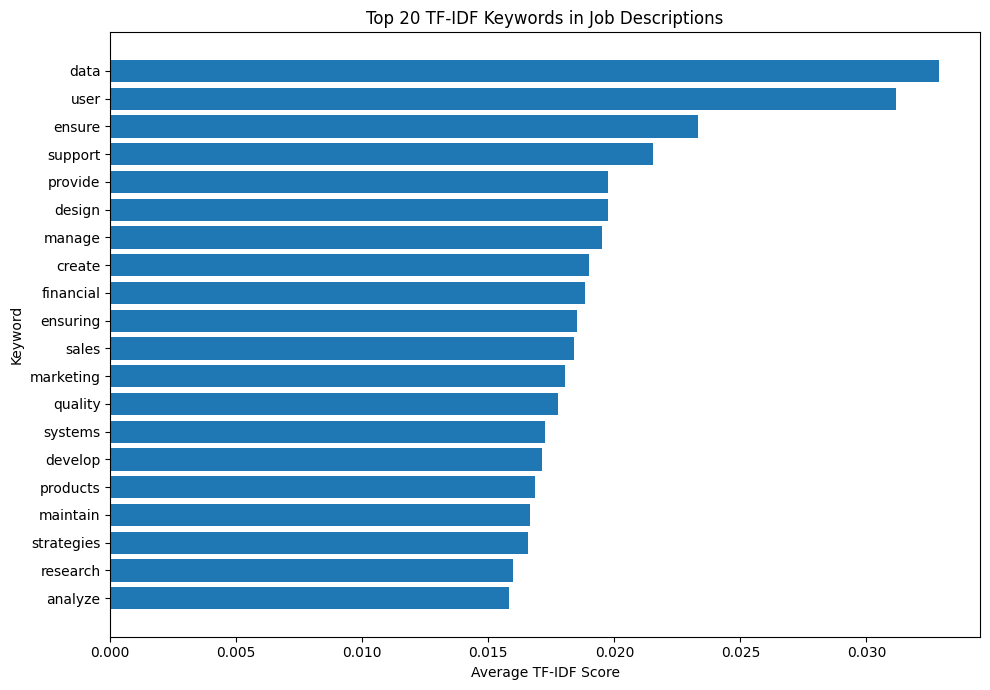

In [ ]:
import matplotlib.pyplot as plt

top_20 = tfidf_df.head(20).sort_values(
    'TF_IDF_Score'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_20['Term'],
    top_20['TF_IDF_Score']
)

plt.title('Top 20 TF-IDF Keywords in Job Descriptions')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(
    df["clean_description"]
)

In [ ]:
terms = vectorizer.get_feature_names_out()

tfidf_scores = np.asarray(
    X.mean(axis=0)
).flatten()

tfidf_df = pd.DataFrame({
    'Term': terms,
    'TF_IDF_Score': tfidf_scores
})

tfidf_df = tfidf_df.sort_values(
    by='TF_IDF_Score',
    ascending=False
)

print(tfidf_df.head(20))

           Term  TF_IDF_Score
205        data      0.030720
953        user      0.024448
325      ensure      0.022248
891     support      0.020191
735     provide      0.019121
371   financial      0.018634
231      design      0.018539
803       sales      0.017960
184      create      0.017933
542      manage      0.017720
902     systems      0.017297
335    ensuring      0.017001
247     develop      0.016727
564   marketing      0.016602
748     quality      0.015928
873  strategies      0.015803
721    products      0.015782
777    research      0.014856
513       legal      0.014796
530    maintain      0.014504


In [ ]:
master_skills = [
    "Python",
    "Java",
    "C++",
    "JavaScript",
    "SQL",
    "MySQL",
    "PostgreSQL",
    "Power BI",
    "Tableau",
    "Excel",
    "AWS",
    "Azure",
    "TensorFlow",
    "Pandas",
    "NumPy",
    "Scikit-learn",
    "Spark",
    "Docker"
]

In [ ]:
tfidf_df['Term_Normalized'] = (
    tfidf_df['Term']
    .str.lower()
    .str.strip()
)

master_skills_normalized = [
    skill.lower().strip()
    for skill in master_skills
]

dictionary_vs_tfidf = tfidf_df[
    tfidf_df['Term_Normalized'].isin(
        master_skills_normalized
    )
]

print(dictionary_vs_tfidf.head())

           Term  TF_IDF_Score Term_Normalized
495        java      0.002611            java
496  javascript      0.001718      javascript


In [ ]:
detected_skills = set(
    dictionary_vs_tfidf['Term_Normalized']
)

master_skill_set = set(
    master_skills_normalized
)

matched_skills = detected_skills.intersection(
    master_skill_set
)

print("Total Master Skills:", len(master_skill_set))
print("Skills Found by TF-IDF:", len(matched_skills))
print("Matched Skills:", matched_skills)

Total Master Skills: 18
Skills Found by TF-IDF: 2
Matched Skills: {'java', 'javascript'}


In [ ]:
coverage = (
    len(matched_skills) /
    len(master_skill_set)
) * 100

print(
    "TF-IDF Skill Coverage:",
    round(coverage, 2),
    "%"
)

TF-IDF Skill Coverage: 11.11 %


In [ ]:
dictionary_skills = set(
    skill.lower()
    for skill in master_skills
)

tfidf_keywords = set(
    tfidf_df['Term_Normalized'].head(100)
)
overlap = dictionary_skills.intersection(
    tfidf_keywords
)

print("Dictionary Skills:")
print(dictionary_skills)

print("\nTF-IDF Keywords:")
print(tfidf_keywords)

print("\nCommon Skills:")
print(overlap)

Dictionary Skills:
{'tableau', 'spark', 'docker', 'sql', 'numpy', 'aws', 'postgresql', 'java', 'python', 'javascript', 'pandas', 'c++', 'azure', 'excel', 'tensorflow', 'mysql', 'scikit-learn', 'power bi'}

TF-IDF Keywords:
{'meet', 'making', 'organization', 'operations', 'teams', 'content', 'optimize', 'maintain', 'conduct', 'compliance', 'enhance', 'social', 'work', 'processes', 'infrastructure', 'customer', 'focus', 'related', 'goals', 'issues', 'develop', 'administrative', 'environmental', 'decisions', 'engineers', 'manager', 'quality', 'efficiency', 'financial', 'strategies', 'network', 'systems', 'maintaining', 'needs', 'digital', 'relationships', 'identify', 'designers', 'products', 'clients', 'provide', 'management', 'services', 'designing', 'technical', 'marketing', 'experience', 'interfaces', 'planning', 'support', 'sales', 'assist', 'manage', 'design', 'implement', 'project', 'designs', 'ensure', 'managing', 'build', 'healthcare', 'product', 'market', 'specialists', 'web', 's

In [ ]:
comparison = pd.DataFrame({
    'TF_IDF_Keyword': tfidf_df.head(30)['Term'],
    'TF_IDF_Score': tfidf_df.head(30)['TF_IDF_Score']
})

comparison['Is_Known_Skill'] = (
    comparison['TF_IDF_Keyword']
    .str.lower()
    .isin(master_skill_set)
)

print(comparison)

    TF_IDF_Keyword  TF_IDF_Score  Is_Known_Skill
205           data      0.030720           False
953           user      0.024448           False
325         ensure      0.022248           False
891        support      0.020191           False
735        provide      0.019121           False
371      financial      0.018634           False
231         design      0.018539           False
803          sales      0.017960           False
184         create      0.017933           False
542         manage      0.017720           False
902        systems      0.017297           False
335       ensuring      0.017001           False
247        develop      0.016727           False
564      marketing      0.016602           False
748        quality      0.015928           False
873     strategies      0.015803           False
721       products      0.015782           False
777       research      0.014856           False
513          legal      0.014796           False
530       maintain  

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    stop_words="english"
)

X = vectorizer.fit_transform(
    df["clean_description"]
)
terms = vectorizer.get_feature_names_out()

print("Total N-Grams:", len(terms))
print(terms[:20])

Total N-Grams: 12094
['abuse' 'abuse develop' 'abuse develop healthier' 'academic'
 'academic development' 'academic development provide'
 'academic knowledge' 'academic scientific'
 'academic scientific inquiries' 'acceptable' 'acceptable agreements'
 'acceptable agreements effective' 'access' 'access data'
 'access data breaches' 'access quality' 'access quality education'
 'accessibility' 'accessibility developer'
 'accessibility developer focuses']


In [ ]:
import numpy as np

tfidf_scores = np.asarray(
    X.mean(axis=0)
).flatten()

ngram_df = pd.DataFrame({
    "Ngram": terms,
    "TF_IDF_Score": tfidf_scores
})

ngram_df = ngram_df.sort_values(
    by="TF_IDF_Score",
    ascending=False
)

print(ngram_df.head(20))

            Ngram  TF_IDF_Score
2701         data      0.016006
11641        user      0.015775
4035       ensure      0.011507
10801     support      0.010431
4564    financial      0.009791
2988       design      0.009548
2460       create      0.009541
8845      provide      0.009397
6560       manage      0.009341
4155     ensuring      0.009150
9687        sales      0.008831
6845    marketing      0.008629
9025      quality      0.008602
10937     systems      0.008362
3169      develop      0.008114
6437     maintain      0.008073
8601     products      0.008024
10560  strategies      0.007987
520       analyze      0.007796
9877     security      0.007751


In [ ]:
unigram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    stop_words="english"
)

X_uni = unigram_vectorizer.fit_transform(
    df["clean_description"]
)

unigram_terms = (
    unigram_vectorizer
    .get_feature_names_out()
)

unigram_scores = np.asarray(
    X_uni.mean(axis=0)
).flatten()

unigram_df = pd.DataFrame({
    "Term": unigram_terms,
    "TF_IDF_Score": unigram_scores
})

unigram_df = unigram_df.sort_values(
    "TF_IDF_Score",
    ascending=False
)

print("Top 20 Unigrams:")
print(unigram_df.head(20))

Top 20 Unigrams:
            Term  TF_IDF_Score
356         data      0.031901
1373        user      0.030577
485       ensure      0.022696
1285     support      0.020994
381       design      0.018928
793       manage      0.018909
1044     provide      0.018815
331       create      0.018531
546    financial      0.018339
487     ensuring      0.018045
805    marketing      0.017517
1146       sales      0.017478
1060     quality      0.017030
1294     systems      0.016684
390      develop      0.016282
1020    products      0.016253
787     maintain      0.016084
1249  strategies      0.015924
83       analyze      0.015420
1171    security      0.015376


In [ ]:
bigram_vectorizer = TfidfVectorizer(
    ngram_range=(2, 2),
    stop_words="english"
)

X_bi = bigram_vectorizer.fit_transform(
    df["clean_description"]
)

bigram_terms = (
    bigram_vectorizer
    .get_feature_names_out()
)

bigram_scores = np.asarray(
    X_bi.mean(axis=0)
).flatten()

bigram_df = pd.DataFrame({
    "Bigram": bigram_terms,
    "TF_IDF_Score": bigram_scores
})

bigram_df = bigram_df.sort_values(
    "TF_IDF_Score",
    ascending=False
)

print("Top 20 Bigrams:")
print(bigram_df.head(20))

Top 20 Bigrams:
                     Bigram  TF_IDF_Score
4201           social media      0.011142
4824        user experience      0.007364
3563      products services      0.006438
4899     visually appealing      0.006425
2776       managers oversee      0.006033
1408     digital interfaces      0.005972
1195        decision making      0.005970
4455           supply chain      0.005588
93    administrators manage      0.004994
4828         user interface      0.004983
3664       provide insights      0.004721
806       computer networks      0.004603
1276       designers create      0.004502
4826          user friendly      0.004382
1719          ensuring data      0.004190
1135            data driven      0.004153
1250       design implement      0.004054
4825       user experiences      0.004018
4910       web applications      0.003991
209            analyze data      0.003910


In [ ]:
trigram_vectorizer = TfidfVectorizer(
    ngram_range=(3, 3),
    stop_words="english"
)

X_tri = trigram_vectorizer.fit_transform(
    df["clean_description"]
)

trigram_terms = (
    trigram_vectorizer
    .get_feature_names_out()
)

trigram_scores = np.asarray(
    X_tri.mean(axis=0)
).flatten()

trigram_df = pd.DataFrame({
    "Trigram": trigram_terms,
    "TF_IDF_Score": trigram_scores
})

trigram_df = trigram_df.sort_values(
    "TF_IDF_Score",
    ascending=False
)

print("Top 20 Trigrams:")
print(trigram_df.head(20))

Top 20 Trigrams:
                               Trigram  TF_IDF_Score
1429    designers specialize designing      0.003854
3620   organizations computer networks      0.003846
1086         cost saving opportunities      0.003375
1969           ensuring data integrity      0.003360
1134        create meaningful engaging      0.003353
2086      experiences considering user      0.003353
2725      interfaces create meaningful      0.003353
5448          user behaviors responses      0.003353
1444       designing user interactions      0.003353
1822         engaging user experiences      0.003353
1592         digital interfaces create      0.003353
939         considering user behaviors      0.003353
3272          meaningful engaging user      0.003353
5468         user interactions digital      0.003353
4857         specialize designing user      0.003353
5459      user experiences considering      0.003353
2713  interaction designers specialize      0.003353
2714   interactions digital i

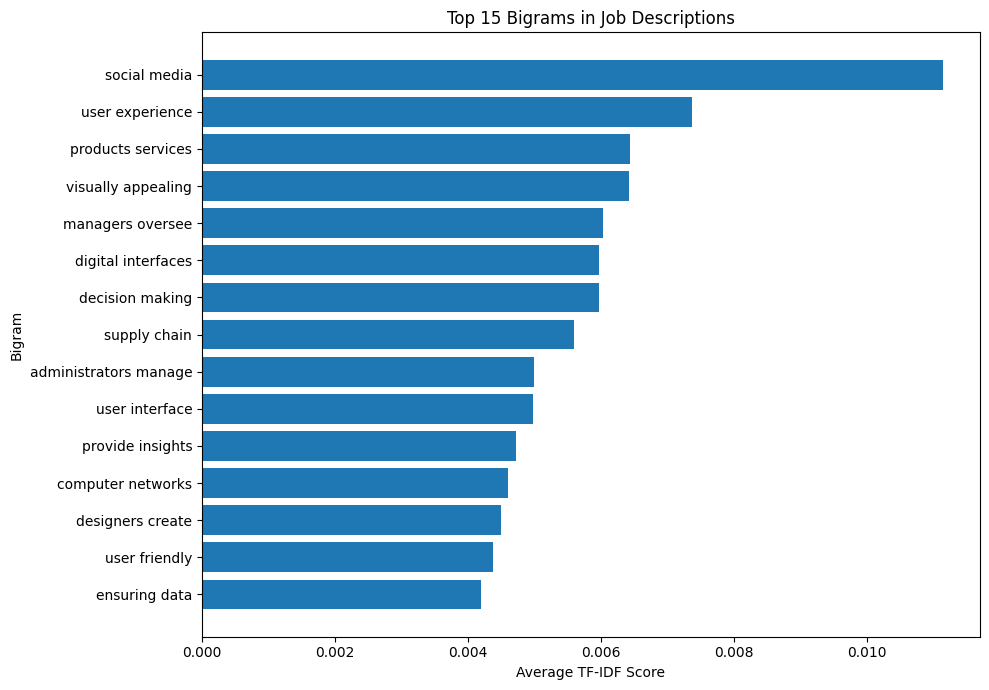

In [ ]:
import matplotlib.pyplot as plt

top_bigrams = bigram_df.head(15).sort_values(
    "TF_IDF_Score"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_bigrams["Bigram"],
    top_bigrams["TF_IDF_Score"]
)

plt.title("Top 15 Bigrams in Job Descriptions")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Bigram")

plt.tight_layout()
plt.show()

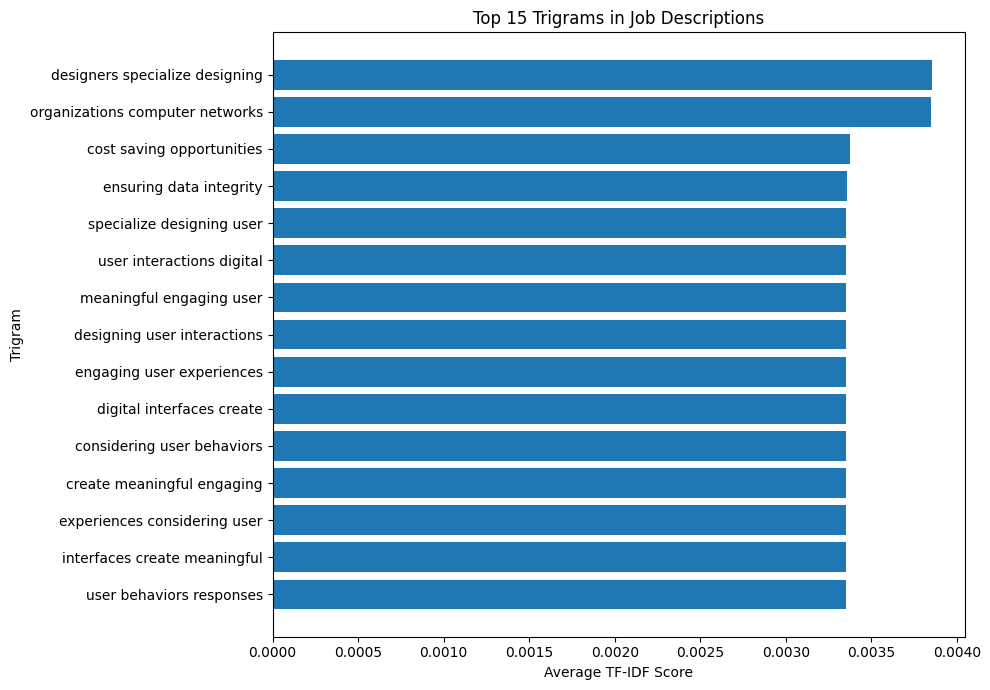

In [ ]:
top_trigrams = trigram_df.head(15).sort_values(
    "TF_IDF_Score"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_trigrams["Trigram"],
    top_trigrams["TF_IDF_Score"]
)

plt.title("Top 15 Trigrams in Job Descriptions")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Trigram")

plt.tight_layout()
plt.show()

In [ ]:
top_bigrams = bigram_df.head(50)

top_trigrams = trigram_df.head(50)

print("Potential Multi-Word Skills — Bigrams")
print(top_bigrams)

print("\nPotential Multi-Word Skills — Trigrams")
print(top_trigrams)

Potential Multi-Word Skills — Bigrams
                       Bigram  TF_IDF_Score
4201             social media      0.011142
4824          user experience      0.007364
3563        products services      0.006438
4899       visually appealing      0.006425
2776         managers oversee      0.006033
1408       digital interfaces      0.005972
1195          decision making      0.005970
4455             supply chain      0.005588
93      administrators manage      0.004994
4828           user interface      0.004983
3664         provide insights      0.004721
806         computer networks      0.004603
1276         designers create      0.004502
4826            user friendly      0.004382
1719            ensuring data      0.004190
1135              data driven      0.004153
1250         design implement      0.004054
4825         user experiences      0.004018
4910         web applications      0.003991
209              analyze data      0.003910
1689           ensure product      0.0

In [ ]:
multi_word_skills = [
    "machine learning",
    "deep learning",
    "power bi",
    "data science",
    "data analysis",
    "natural language processing",
    "computer vision",
    "cloud computing",
    "business intelligence"
]
multi_word_skills = [
    skill.lower()
    for skill in multi_word_skills
]
ngram_skill_matches = ngram_df[
    ngram_df["Ngram"].isin(multi_word_skills)
]

print(ngram_skill_matches)

                      Ngram  TF_IDF_Score
6430       machine learning      0.000996
2702          data analysis      0.000977
1275  business intelligence      0.000576


In [ ]:
known_skills = set(
    skill.lower()
    for skill in multi_word_skills
)

candidate_skills = ngram_df[
    ~ngram_df["Ngram"].isin(known_skills)
].head(10)

print(candidate_skills)

           Ngram  TF_IDF_Score
2701        data      0.016006
11641       user      0.015775
4035      ensure      0.011507
10801    support      0.010431
4564   financial      0.009791
2988      design      0.009548
2460      create      0.009541
8845     provide      0.009397
6560      manage      0.009341
4155    ensuring      0.009150


TOP 30 N-GRAMS
            Ngram  TF_IDF_Score
1122         data      0.019599
4781         user      0.018507
1707       ensure      0.015446
4494      support      0.014119
1933    financial      0.013692
3702      provide      0.013139
1257       design      0.013072
2770       manage      0.012653
4064        sales      0.012549
1336      develop      0.012379
2885    marketing      0.012238
4540      systems      0.012085
1759     ensuring      0.012077
995        create      0.011953
3767      quality      0.011790
4391   strategies      0.011208
3600     products      0.010838
3923     research      0.010690
3369  performance      0.010630
2635        legal      0.010528
4147     security      0.010200
4955         work      0.010140
2710     maintain      0.010106
198       analyze      0.009969
505      business      0.009765
3575      product      0.009759
864       content      0.009647
2293      improve      0.009022
2326    including      0.008991
3100      network      0.

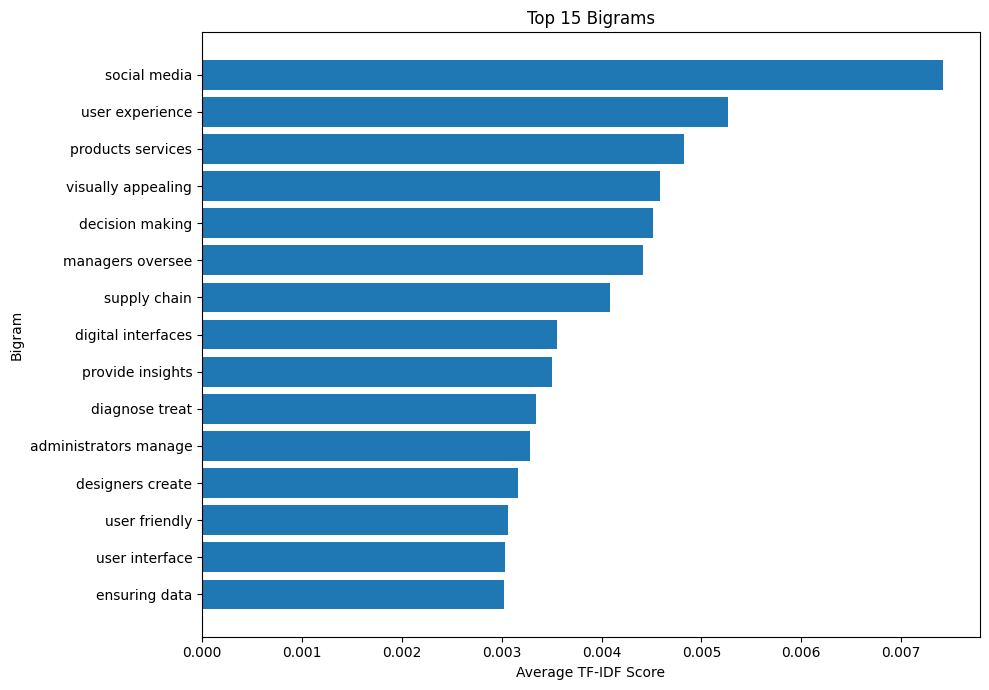

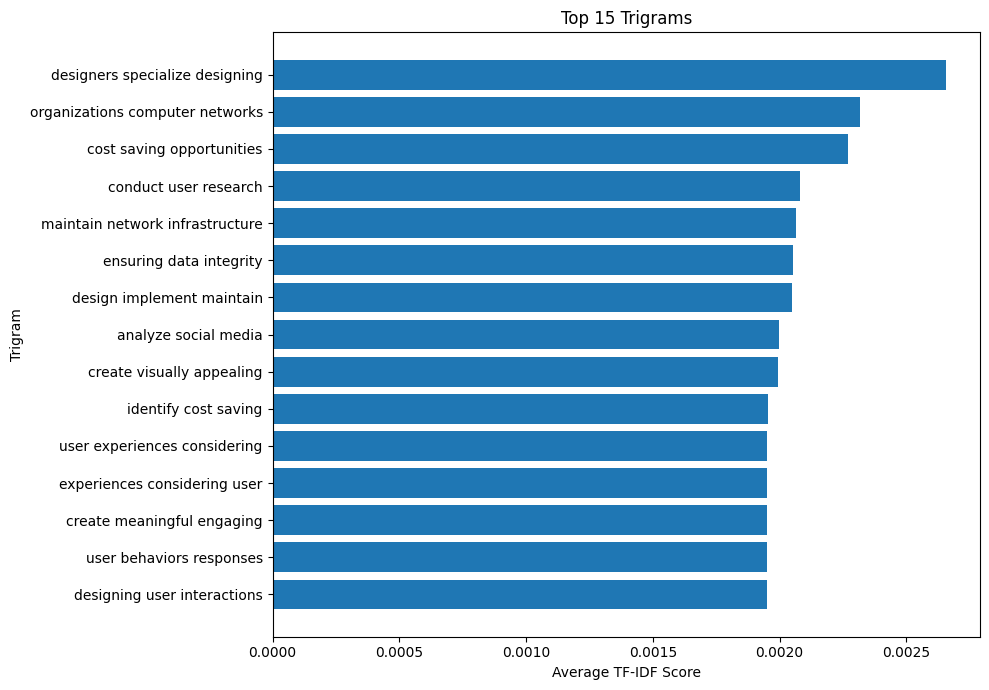

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer


# ==========================================
# N-GRAM ANALYSIS
# ==========================================

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    stop_words="english",
    max_features=5000
)

# Transform job descriptions
X = vectorizer.fit_transform(
    df["clean_description"]
)

# Get terms
terms = vectorizer.get_feature_names_out()

# Calculate average TF-IDF score
scores = np.asarray(
    X.mean(axis=0)
).flatten()

# Create DataFrame
ngram_df = pd.DataFrame({
    "Ngram": terms,
    "TF_IDF_Score": scores
})

# Sort
ngram_df = ngram_df.sort_values(
    "TF_IDF_Score",
    ascending=False
)

print("=" * 50)
print("TOP 30 N-GRAMS")
print("=" * 50)

print(ngram_df.head(30))


# ==========================================
# BIGRAM ANALYSIS
# ==========================================

bigram_df = ngram_df[
    ngram_df["Ngram"].str.split().str.len() == 2
]

print("\nTOP 20 BIGRAMS")
print(bigram_df.head(20))


# ==========================================
# TRIGRAM ANALYSIS
# ==========================================

trigram_df = ngram_df[
    ngram_df["Ngram"].str.split().str.len() == 3
]

print("\nTOP 20 TRIGRAMS")
print(trigram_df.head(20))


# ==========================================
# VISUALIZE BIGRAMS
# ==========================================

top_bigrams = bigram_df.head(15).sort_values(
    "TF_IDF_Score"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_bigrams["Ngram"],
    top_bigrams["TF_IDF_Score"]
)

plt.title("Top 15 Bigrams")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Bigram")

plt.tight_layout()
plt.show()


# ==========================================
# VISUALIZE TRIGRAMS
# ==========================================

top_trigrams = trigram_df.head(15).sort_values(
    "TF_IDF_Score"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_trigrams["Ngram"],
    top_trigrams["TF_IDF_Score"]
)

plt.title("Top 15 Trigrams")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Trigram")

plt.tight_layout()
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
pairs = [
    ("ML", "Machine Learning"),
    ("AI", "Artificial Intelligence"),
    ("PowerBI", "Power BI"),
    ("Postgre SQL", "PostgreSQL"),
    ("sklearn", "Scikit-learn"),
    ("AWS", "Amazon Web Services"),
    ("NLP", "Natural Language Processing"),
    ("CV", "Computer Vision")
]

In [ ]:
from sentence_transformers import util

phrases = [
    "ML",
    "Machine Learning"
]

phrase_embeddings = model.encode(
    phrases,
    convert_to_tensor=True
)

similarity = util.cos_sim(
    phrase_embeddings[0],
    phrase_embeddings[1]
)

print(
    "Similarity between ML and Machine Learning:",
    float(similarity)
)

Similarity between ML and Machine Learning: 0.3726634979248047


In [ ]:
for phrase1, phrase2 in pairs:

    embeddings = model.encode(
        [phrase1, phrase2],
        convert_to_tensor=True
    )

    score = util.cos_sim(
        embeddings[0],
        embeddings[1]
    )

    print(
        f"{phrase1} ↔ {phrase2}: "
        f"{float(score):.4f}"
    )

ML ↔ Machine Learning: 0.3727
AI ↔ Artificial Intelligence: 0.7912
PowerBI ↔ Power BI: 0.6816
Postgre SQL ↔ PostgreSQL: 0.8761
sklearn ↔ Scikit-learn: 0.5961
AWS ↔ Amazon Web Services: 0.6605
NLP ↔ Natural Language Processing: 0.6022
CV ↔ Computer Vision: 0.2607


In [ ]:
skill_embeddings = model.encode(
    skill_dictionary,
    convert_to_tensor=True
)

job_text = """
We are looking for a data scientist with experience
in ML, Python, SQL and cloud technologies.
Experience with NLP is preferred.
"""

job_embedding = model.encode(
    job_text,
    convert_to_tensor=True
)
similarities = util.cos_sim(
    job_embedding,
    skill_embeddings
)[0]

import pandas as pd

results = pd.DataFrame({
    "Skill": skill_dictionary,
    "Similarity": similarities.cpu().numpy()
})

results = results.sort_values(
    "Similarity",
    ascending=False
)

print(results)

                          Skill  Similarity
8                  Data Science    0.452528
0                        Python    0.334914
2                           SQL    0.322024
6   Natural Language Processing    0.261231
9                 Data Analysis    0.250706
13                 Scikit-learn    0.194799
12                   PostgreSQL    0.192626
4              Machine Learning    0.183437
11                        Azure    0.173574
5                 Deep Learning    0.165313
10                          AWS    0.147677
1                          Java    0.131393
7               Computer Vision    0.048571
3                      Power BI    0.044424
14                       Docker    0.001942


In [ ]:
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt_tab', quiet=True)

sentences = sent_tokenize(job_text)

print(sentences)

['\nWe are looking for a data scientist with experience\nin ML, Python, SQL and cloud technologies.', 'Experience with NLP is preferred.']


In [ ]:
sentence_embeddings = model.encode(
    sentences,
    convert_to_tensor=True
)

similarity_matrix = util.cos_sim(
    sentence_embeddings,
    skill_embeddings
)

for i, sentence in enumerate(sentences):

    scores = similarity_matrix[i]

    best_index = scores.argmax()

    best_skill = skill_dictionary[best_index]

    best_score = float(scores[best_index])

    print(
        f"\nSentence: {sentence}"
    )

    print(
        f"Possible Skill: {best_skill}"
    )

    print(
        f"Similarity: {best_score:.4f}"
    )


Sentence: 
We are looking for a data scientist with experience
in ML, Python, SQL and cloud technologies.
Possible Skill: Data Science
Similarity: 0.5204

Sentence: Experience with NLP is preferred.
Possible Skill: Natural Language Processing
Similarity: 0.5031


In [ ]:
pip install spacy

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [ ]:
text = """
Python developer working with Microsoft,
AWS, Google Cloud and New York office.
"""

doc = nlp(text)

for ent in doc.ents:
    print(
        ent.text,
        "->",
        ent.label_
    )

Microsoft -> ORG
Google Cloud -> PERSON
New York -> GPE


In [ ]:
CUSTOM_ENTITIES = [
    "SKILL",
    "TOOL",
    "TECHNOLOGY",
    "DATABASE",
    "CLOUD_PLATFORM"
]
TRAIN_DATA = [
    (
        "Experience with Python and AWS.",
        {
            "entities": [
                (17, 23, "SKILL"),
                (28, 31, "CLOUD_PLATFORM")
            ]
        }
    ),

    (
        "Knowledge of PostgreSQL and Power BI.",
        {
            "entities": [
                (16, 26, "DATABASE"),
                (31, 39, "TOOL")
            ]
        }
    )
]

TRAIN_DATA = [
    (
        "Experience with Python and AWS.",
        {
            "entities": [
                (16, 22, "SKILL"),
                (27, 30, "CLOUD_PLATFORM")
            ]
        }
    ),

    (
        "Knowledge of PostgreSQL and Power BI.",
        {
            "entities": [
                (14, 24, "DATABASE"),
                (29, 37, "TOOL")
            ]
        }
    ),

    (
        "Strong skills in Java and MySQL.",
        {
            "entities": [
                (17, 21, "SKILL"),
                (26, 31, "DATABASE")
            ]
        }
    ),

    (
        "Experience with Docker and Azure.",
        {
            "entities": [
                (16, 22, "TOOL"),
                (27, 32, "CLOUD_PLATFORM")
            ]
        }
    ),

    (
        "Expertise in TensorFlow and Python.",
        {
            "entities": [
                (14, 24, "TECHNOLOGY"),
                (29, 35, "SKILL")
            ]
        }
    ),

    (
        "Knowledge of SQL, Tableau and AWS.",
        {
            "entities": [
                (14, 17, "DATABASE"),
                (19, 26, "TOOL"),
                (31, 34, "CLOUD_PLATFORM")
            ]
        }
    )
]

def create_training_example(text, entities):

    entity_spans = []

    for entity_text, label in entities:

        start = text.find(entity_text)

        if start == -1:
            continue

        end = start + len(entity_text)

        entity_spans.append(
            (start, end, label)
        )

    return (
        text,
        {
            "entities": entity_spans
        }
    )

In [ ]:
example = create_training_example(
    "Experience with Python and AWS.",
    [
        ("Python", "SKILL"),
        ("AWS", "CLOUD_PLATFORM")
    ]
)

print(example)

('Experience with Python and AWS.', {'entities': [(16, 22, 'SKILL'), (27, 30, 'CLOUD_PLATFORM')]})


In [ ]:
from spacy import displacy

displacy.render(
    doc,
    style="ent",
    jupyter=True
)

In [ ]:
pip install pandas scikit-learn joblib

In [ ]:
import pandas as pd
df = pd.read_csv("/Skill.csv")
print(df.head())
print(df.shape)
print(df["label"].value_counts())

         text        label
0      Python  Programming
1        Java  Programming
2         C++  Programming
3  JavaScript  Programming
4         SQL     Database
(21, 2)
label
Programming         4
Database            4
Machine Learning    4
Cloud               3
BI Tool             3
Data Analytics      3
Name: count, dtype: int64


In [ ]:
X = df["text"]
y = df["label"]
print(X)
print(y)

0           Python
1             Java
2              C++
3       JavaScript
4              SQL
5            MySQL
6       PostgreSQL
7          MongoDB
8              AWS
9            Azure
10             GCP
11        Power BI
12         Tableau
13           Excel
14          Pandas
15           NumPy
16     Power Query
17    Scikit-learn
18      TensorFlow
19         PyTorch
20           Keras
Name: text, dtype: object
0          Programming
1          Programming
2          Programming
3          Programming
4             Database
5             Database
6             Database
7             Database
8                Cloud
9                Cloud
10               Cloud
11             BI Tool
12             BI Tool
13             BI Tool
14      Data Analytics
15      Data Analytics
16      Data Analytics
17    Machine Learning
18    Machine Learning
19    Machine Learning
20    Machine Learning
Name: label, dtype: object


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 14
Testing records: 7


### Train a Classification Model

Now that we have prepared our data and split it into training and testing sets, we will train a classification model. For this example, we'll use a `LogisticRegression` model from `scikit-learn`, a common choice for text classification due to its simplicity and effectiveness.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets

# Initialize a TfidfVectorizer for the skill names
# max_features can be adjusted, but for skill names, it might be small enough
# Not using stop_words here as skill names are often short and relevant words
skill_vectorizer = TfidfVectorizer()

# Fit and transform X_train and transform X_test
X_train_vectorized = skill_vectorizer.fit_transform(X_train)
X_test_vectorized = skill_vectorizer.transform(X_test)

# Train the model
model.fit(X_train_vectorized, y_train)

print("Model training complete!")

Model training complete!


### Evaluate Model Performance

After training, it's crucial to evaluate how well our model performs on unseen data. We'll use several metrics to get a comprehensive understanding:

*   **Accuracy:** The proportion of correctly classified instances.
*   **Precision:** The proportion of true positive predictions among all positive predictions.
*   **Recall:** The proportion of true positive predictions among all actual positive instances.
*   **F1-Score:** The harmonic mean of precision and recall, providing a balance between the two.
*   **Confusion Matrix:** A table that visualizes the performance of a classification model, showing true positives, true negatives, false positives, and false negatives.

Accuracy: 0.1429
Precision: 0.0238
Recall: 0.1429
F1-Score: 0.0408

Classification Report:
                  precision    recall  f1-score   support

         BI Tool       0.00      0.00      0.00         1
           Cloud       0.00      0.00      0.00         1
  Data Analytics       0.00      0.00      0.00         1
        Database       0.17      1.00      0.29         1
Machine Learning       0.00      0.00      0.00         1
     Programming       0.00      0.00      0.00         2

        accuracy                           0.14         7
       macro avg       0.03      0.17      0.05         7
    weighted avg       0.02      0.14      0.04         7



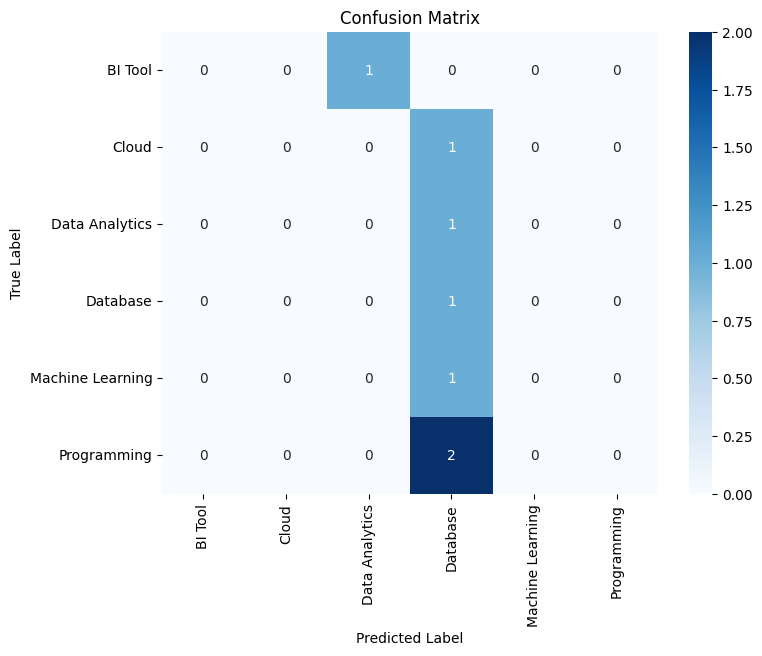

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(X_test_vectorized)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)


(14, 17)
(7, 17)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")
y_pred = model.predict(X_test_tfidf)

print(y_pred)

Model training completed!
['Machine Learning' 'Machine Learning' 'Data Analytics' 'Machine Learning'
 'Machine Learning' 'Machine Learning' 'Machine Learning']


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy %:", round(accuracy * 100, 2))

print(classification_report(y_test, y_pred))

Accuracy: 0.14285714285714285
Accuracy %: 14.29
                  precision    recall  f1-score   support

         BI Tool       0.00      0.00      0.00         1
           Cloud       0.00      0.00      0.00         1
  Data Analytics       0.00      0.00      0.00         1
        Database       0.00      0.00      0.00         1
Machine Learning       0.17      1.00      0.29         1
     Programming       0.00      0.00      0.00         2

        accuracy                           0.14         7
       macro avg       0.03      0.17      0.05         7
    weighted avg       0.02      0.14      0.04         7



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


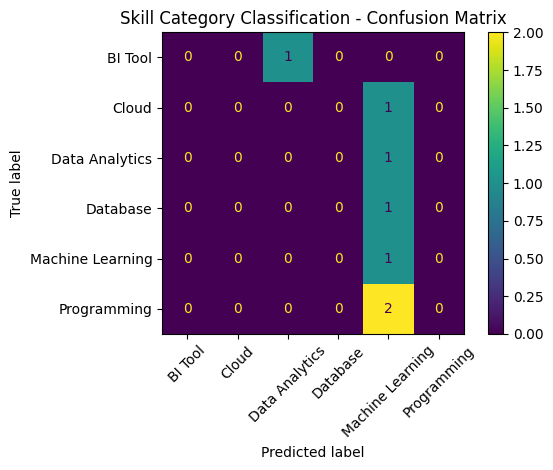

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Skill Category Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
new_skills = [
    "Python",
    "SQL",
    "Power BI",
    "AWS",
    "Tableau",
    "Java",
    "Pandas",
    "TensorFlow"
]
new_tfidf = vectorizer.transform(new_skills)

predictions = model.predict(new_tfidf)

for skill, category in zip(new_skills, predictions):
    print(f"{skill} → {category}")

Python → Machine Learning
SQL → Database
Power BI → Data Analytics
AWS → Cloud
Tableau → BI Tool
Java → Programming
Pandas → Machine Learning
TensorFlow → Machine Learning


Dataset shape: (21, 2)

Category distribution:
label
Programming         4
Database            4
Machine Learning    4
Cloud               3
BI Tool             3
Data Analytics      3
Name: count, dtype: int64

Accuracy: 14.29 %

Classification Report:
                  precision    recall  f1-score   support

         BI Tool       0.00      0.00      0.00         1
           Cloud       0.00      0.00      0.00         1
  Data Analytics       0.00      0.00      0.00         1
        Database       0.00      0.00      0.00         1
Machine Learning       0.17      1.00      0.29         1
     Programming       0.00      0.00      0.00         2

        accuracy                           0.14         7
       macro avg       0.03      0.17      0.05         7
    weighted avg       0.02      0.14      0.04         7



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


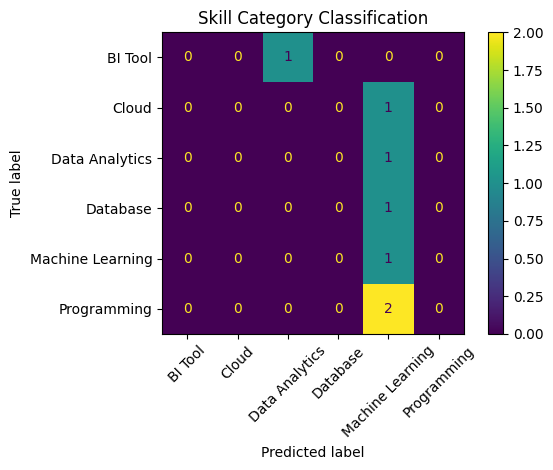


New Skill Predictions:
Python → Machine Learning
SQL → Database
Power BI → Data Analytics
AWS → Cloud
Tableau → BI Tool
Java → Programming
Pandas → Machine Learning
TensorFlow → Machine Learning


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
df = pd.read_csv("/Skill.csv")

print("Dataset shape:", df.shape)
print("\nCategory distribution:")
print(df["label"].value_counts())

df = df.dropna(subset=["text", "label"])

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)


# -----------------------------------
# 7. Prediction
# -----------------------------------

y_pred = model.predict(X_test_tfidf)


# -----------------------------------
# 8. Evaluation
# -----------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# -----------------------------------
# 9. Confusion Matrix
# -----------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)

plt.title("Skill Category Classification")
plt.tight_layout()
plt.show()


# -----------------------------------
# 10. Test New Skills
# -----------------------------------

new_skills = [
    "Python",
    "SQL",
    "Power BI",
    "AWS",
    "Tableau",
    "Java",
    "Pandas",
    "TensorFlow"
]

new_tfidf = vectorizer.transform(new_skills)

predictions = model.predict(new_tfidf)

print("\nNew Skill Predictions:")

for skill, category in zip(new_skills, predictions):
    print(f"{skill} → {category}")

In [ ]:
import joblib

joblib.dump(model, "skill_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model saved successfully.")
model = joblib.load("skill_classifier.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

Model saved successfully.


In [ ]:
training_data = [
    {
        "text": "Experience with Python, SQL and AWS.",
        "entities": [
            (16, 22, "SKILL"),
            (24, 27, "SKILL"),
            (32, 35, "SKILL")
        ]
    },
    {
        "text": "Knowledge of Java, Spring Boot and MySQL.",
        "entities": [
            (16, 20, "SKILL"),
            (22, 33, "SKILL"),
            (38, 43, "SKILL")
        ]
    }
]

In [ ]:
from transformers import pipeline

ner = pipeline(
    "ner",
    aggregation_strategy="simple"
)

text = "Experience with Python, SQL and AWS."

results = ner(text)

for result in results:
    print(result)

[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.33GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

{'entity_group': 'MISC', 'score': np.float32(0.9135594), 'word': 'Python', 'start': 16, 'end': 22}
{'entity_group': 'MISC', 'score': np.float32(0.6791191), 'word': 'SQL', 'start': 24, 'end': 27}
{'entity_group': 'MISC', 'score': np.float32(0.54898435), 'word': 'A', 'start': 32, 'end': 33}
{'entity_group': 'ORG', 'score': np.float32(0.47517568), 'word': '##WS', 'start': 33, 'end': 35}


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

text = "Experience with Python, SQL and AWS."

tokens = tokenizer.tokenize(text)

print(tokens)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

['experience', 'with', 'python', ',', 'sql', 'and', 'aw', '##s', '.']


In [ ]:
encoded = tokenizer(
    text,
    return_tensors="pt"
)

print(encoded)

{'input_ids': tensor([[  101,  3325,  2007, 18750,  1010, 29296,  1998, 22091,  2015,  1012,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification
)

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=3
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
label2id = {
    "O": 0,
    "B-SKILL": 1,
    "I-SKILL": 2
}

id2label = {
    0: "O",
    1: "B-SKILL",
    2: "I-SKILL"
}
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import pandas as pd
df = pd.read_csv("/text,actual_skills.csv")

def calculate_metrics(actual, predicted):

    actual = set(actual)
    predicted = set(predicted)

    tp = len(actual & predicted)
    fp = len(predicted - actual)
    fn = len(actual - predicted)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    return precision, recall, f1


In [ ]:
actual = ["Python", "SQL", "AWS"]

predicted = ["Python", "SQL", "Java"]

precision, recall, f1 = calculate_metrics(
    actual,
    predicted
)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1: 0.6666666666666666


In [ ]:
import pandas as pd

results = {
    "Dictionary": ["Python", "SQL"],
    "Regex": ["Python", "SQL", "AWS"],
    "TF-IDF": ["Python", "AWS"],
    "NER": ["Python"],
    "ML Model": ["Python", "SQL", "AWS"],
    "Transformer": ["Python", "SQL", "AWS"]
}

actual = ["Python", "SQL", "AWS"]

plot_data = []

for model_name, predictions in results.items():

    precision, recall, f1 = calculate_metrics(
        actual,
        predictions
    )

    print(model_name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print()

    plot_data.append({
        "Model": model_name,
        "F1": f1
    })

f1_scores_df = pd.DataFrame(plot_data)

Dictionary
Precision: 1.0
Recall: 0.6666666666666666
F1: 0.8

Regex
Precision: 1.0
Recall: 1.0
F1: 1.0

TF-IDF
Precision: 1.0
Recall: 0.6666666666666666
F1: 0.8

NER
Precision: 1.0
Recall: 0.3333333333333333
F1: 0.5

ML Model
Precision: 1.0
Recall: 1.0
F1: 1.0

Transformer
Precision: 1.0
Recall: 1.0
F1: 1.0



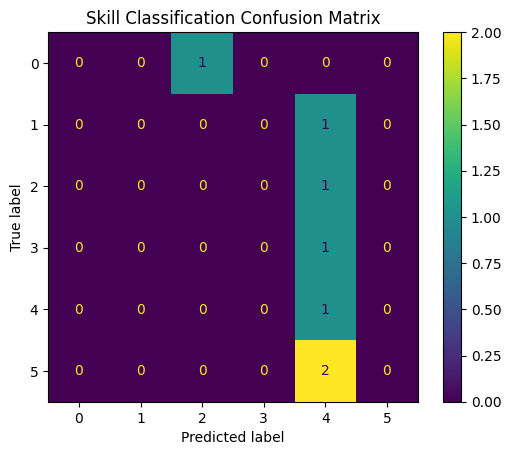

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

display.plot()
plt.title("Skill Classification Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

                  precision    recall  f1-score   support

         BI Tool       0.00      0.00      0.00         1
           Cloud       0.00      0.00      0.00         1
  Data Analytics       0.00      0.00      0.00         1
        Database       0.00      0.00      0.00         1
Machine Learning       0.17      1.00      0.29         1
     Programming       0.00      0.00      0.00         2

        accuracy                           0.14         7
       macro avg       0.03      0.17      0.05         7
    weighted avg       0.02      0.14      0.04         7



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


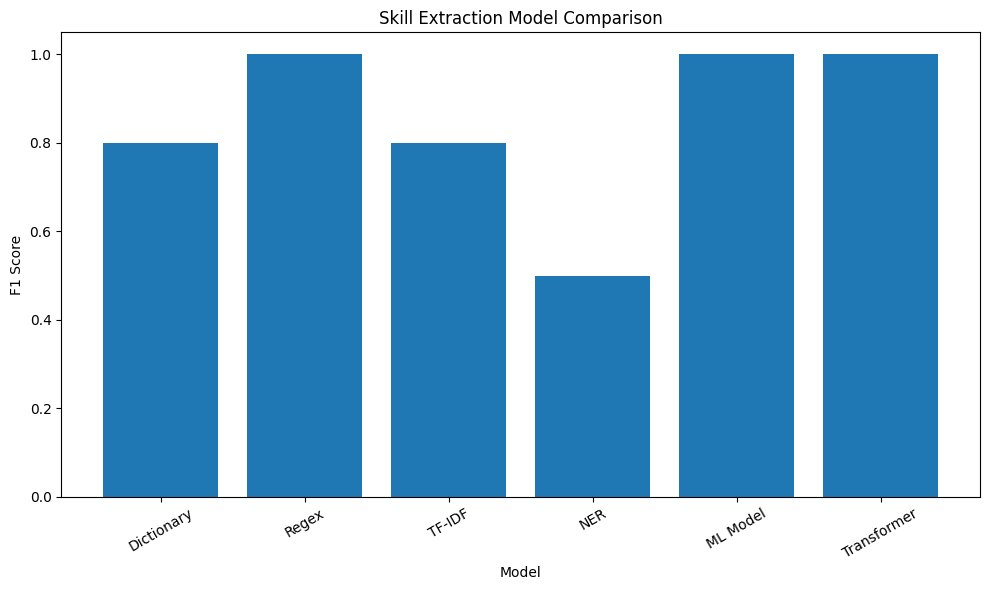

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.bar(
    f1_scores_df["Model"],
    f1_scores_df["F1"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Skill Extraction Model Comparison")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
text = [ "Python 3" , "ML","AWS cloud"]

actual = ["Python", "Machine Learning","AWS"]

predicted = ["Python 3", "ML","AWS cloud"]

print("Actual:", actual)
print("Predicted:", predicted)

Actual: ['Python', 'Machine Learning', 'AWS']
Predicted: ['Python 3', 'ML', 'AWS cloud']


In [ ]:
actual_set = set(actual)
predicted_set = set(predicted)

false_positive = predicted_set - actual_set
false_negative = actual_set - predicted_set

print("False Positives:", false_positive)
print("False Negatives:", false_negative)

False Positives: {'AWS cloud', 'ML', 'Python 3'}
False Negatives: {'Python', 'AWS', 'Machine Learning'}


In [ ]:
skill_synonyms = {
    "python 3": "python",
    "python3": "python",
    "python programming": "python",

    "ml": "machine learning",
    "machine-learning": "machine learning",

    "postgres": "postgresql",
    "postgres sql": "postgresql",

    "powerbi": "power bi",
    "power-bi": "power bi"
}
def normalize_skill(skill):
    skill = skill.lower().strip()
    return skill_synonyms.get(
        skill,
        skill
    )

#     print(normalize_skill("Python 3"))
# print(normalize_skill("ML"))

In [ ]:
print(normalize_skill("Python 3"))
print(normalize_skill("ML"))

python
machine learning


In [ ]:
actual_normalized = [
    normalize_skill(skill)
    for skill in actual
]

predicted_normalized = [
    normalize_skill(skill)
    for skill in predicted
]

print(actual_normalized)
print(predicted_normalized)

['python', 'machine learning', 'aws']
['python', 'machine learning', 'aws cloud']


In [ ]:
error_counts = {
    "False Positive": 12,
    "False Negative": 18,
    "Wrong Entity": 7,
    "Partial Entity": 15,
    "Duplicate Skill": 4,
    "Unknown Skill": 10,
    "Synonym Problem": 14,
    "Spelling Problem": 6
}

import pandas as pd

error_df = pd.DataFrame(
    list(error_counts.items()),
    columns=["Error Category", "Count"]
)

print(error_df)

     Error Category  Count
0    False Positive     12
1    False Negative     18
2      Wrong Entity      7
3    Partial Entity     15
4   Duplicate Skill      4
5     Unknown Skill     10
6   Synonym Problem     14
7  Spelling Problem      6


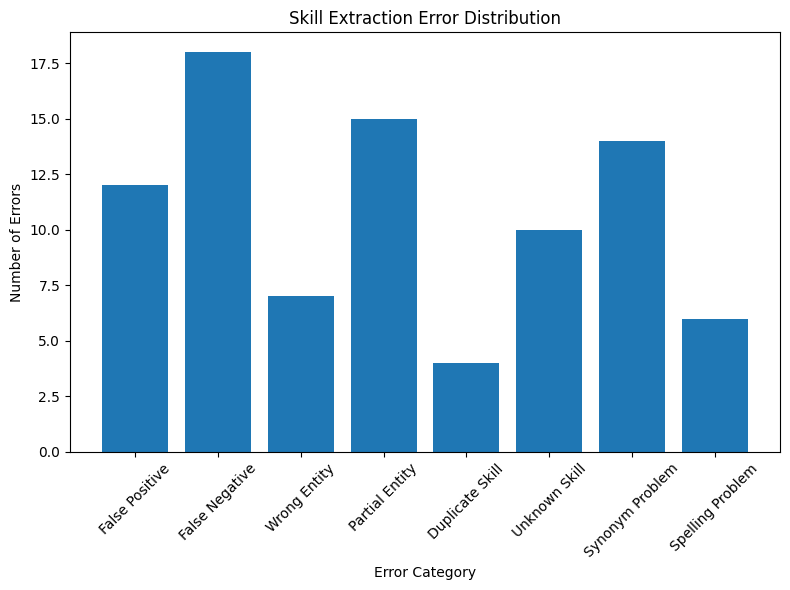

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.bar(
    error_df["Error Category"],
    error_df["Count"]
)
plt.xlabel("Error Category")
plt.ylabel("Number of Errors")
plt.title("Skill Extraction Error Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import re
SKILL_ALIASES = {

    # Python
    "python": "Python",
    "python3": "Python",
    "python 3": "Python",
    "python programming": "Python",
    "py": "Python",

    # Power BI
    "powerbi": "Power BI",
    "power bi": "Power BI",
    "power-bi": "Power BI",
    "power bi desktop": "Power BI",

    # SQL
    "sql": "SQL",
    "sql server": "SQL Server",
    "mssql": "SQL Server",
    "ms sql": "SQL Server",

    # PostgreSQL
    "postgres": "PostgreSQL",
    "postgresql": "PostgreSQL",
    "postgre sql": "PostgreSQL",
    "postgre-sql": "PostgreSQL",

    # Excel
    "excel": "Excel",
    "ms excel": "Excel",
    "microsoft excel": "Excel",

    # Java
    "java": "Java",
    "java programming": "Java",

    # JavaScript
    "javascript": "JavaScript",
    "java script": "JavaScript",
    "js": "JavaScript",

    # React
    "react": "React",
    "reactjs": "React",
    "react.js": "React",

    # AWS
    "aws": "AWS",
    "amazon web services": "AWS",

    # Azure
    "azure": "Microsoft Azure",
    "microsoft azure": "Microsoft Azure",

    # Tableau
    "tableau": "Tableau",

    # Machine Learning
    "machine learning": "Machine Learning",
    "ml": "Machine Learning",

    # Artificial Intelligence
    "artificial intelligence": "Artificial Intelligence",
    "ai": "Artificial Intelligence"
}



def clean_skill(skill):
    """
    Clean raw skill before alias matching.
    """

    skill = skill.lower().strip()

    # Replace special characters with spaces
    skill = re.sub(r"[^a-z0-9+#.\s-]", " ", skill)

    # Replace hyphens with spaces
    skill = skill.replace("-", " ")

    # Remove extra spaces
    skill = re.sub(r"\s+", " ", skill)

    return skill.strip()


def normalize_skill(skill):
    """
    Convert raw skill into canonical skill name.
    """

    cleaned_skill = clean_skill(skill)

    if cleaned_skill in SKILL_ALIASES:
        return SKILL_ALIASES[cleaned_skill]

    return skill.strip()

In [ ]:
test_skills = [
    "Python",
    "python3",
    "Python 3",
    "Python programming",
    "PowerBI",
    "Power BI",
    "Power-BI",
    "postgres",
    "PostgreSQL",
    "Postgre SQL",
    "MS Excel",
    "ReactJS",
    "Java Script",
    "AWS"
]


for skill in test_skills:
    print(f"{skill:25} -> {normalize_skill(skill)}")

Python                    -> Python
python3                   -> Python
Python 3                  -> Python
Python programming        -> Python
PowerBI                   -> Power BI
Power BI                  -> Power BI
Power-BI                  -> Power BI
postgres                  -> PostgreSQL
PostgreSQL                -> PostgreSQL
Postgre SQL               -> PostgreSQL
MS Excel                  -> Excel
ReactJS                   -> React
Java Script               -> JavaScript
AWS                       -> AWS


In [ ]:
import re
class SkillNormalizer:
    def __init__(self, aliases):
        self.aliases = aliases

    def clean(self, skill):

        skill = skill.lower().strip()

        skill = skill.replace("-", " ")

        skill = re.sub(r"\s+", " ", skill)

        return skill

    def normalize(self, skill):

        cleaned = self.clean(skill)

        return self.aliases.get(
            cleaned,
            skill.strip()
        )

SKILL_ALIASES = {
    "python": "Python",
    "python3": "Python",
    "python 3": "Python",
    "python programming": "Python",

    "powerbi": "Power BI",
    "power bi": "Power BI",
    "power bi desktop": "Power BI",

    "power-bi": "Power BI",

    "postgres": "PostgreSQL",
    "postgresql": "PostgreSQL",
    "postgre sql": "PostgreSQL",

    "ms excel": "Excel",
    "microsoft excel": "Excel",
    "excel": "Excel",

    "reactjs": "React",
    "react.js": "React",
    "react": "React",

    "javascript": "JavaScript",
    "java script": "JavaScript",
    "js": "JavaScript"
}
normalizer = SkillNormalizer(SKILL_ALIASES)
skills = [
    "Python3",
    "Python 3",
    "Power-BI",
    "PowerBI",
    "postgres",
    "MS Excel",
    "ReactJS",
    "Java Script"
]
for skill in skills:
    print(skill, "->", normalizer.normalize(skill))

Python3 -> Python
Python 3 -> Python
Power-BI -> Power BI
PowerBI -> Power BI
postgres -> PostgreSQL
MS Excel -> Excel
ReactJS -> React
Java Script -> JavaScript


Python
